In [2]:
import mne
import numpy as np
#import seaborn as sns
import matplotlib.pyplot as plt
#from autoreject import AutoReject
from mne.preprocessing import ICA
from scipy.stats import ttest_rel
import os
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import statsmodels as smf
import sklearn

In [3]:
sns.set(style="whitegrid", context="talk")

In [19]:
file_path = "P07.bdf"

In [20]:
raw = mne.io.read_raw_bdf(file_path, preload=True)

Extracting BDF parameters from P07.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 118999  =      0.000 ...   475.996 secs...


In [14]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, Accel X, ...
 chs: 11 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2026-02-11 03:37:00 UTC
 nchan: 11
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [15]:
channel_mappings = {
    'small': {
        'EEG 4': 'P4',
        'EEG 6': 'Fz',
        'EEG 7': 'P3'
    },
    'medium': {
        'EEG 1': 'P3',
        'EEG 2': 'Fz',
        'EEG 3': 'P4'
    },
    'large': {
        'EEG 1': 'P3',
        'EEG 5': 'P4',
        'EEG 8': 'Fz'
    }
}


In [16]:
headset_size = input("Enter headset size (small, medium, large): ").strip().lower()
if headset_size not in channel_mappings:
    raise ValueError("Invalid headset size! Must be 'small', 'medium', or 'large'.")

mapping_to_use = channel_mappings[headset_size]
#Rename channels
raw.rename_channels(mapping_to_use)
#Remove channels not needed
channels_of_interest = ['Fz', 'P3', 'P4']
raw.pick(channels_of_interest)


Enter headset size (small, medium, large):  large


<RawBDF | P07.bdf, 3 x 119000 (476.0 s), ~2.7 MiB, data loaded>

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 3 channels (please be patient, this may take a while)
Selecting by explained variance: 2 components
Fitting ICA took 0.2s.


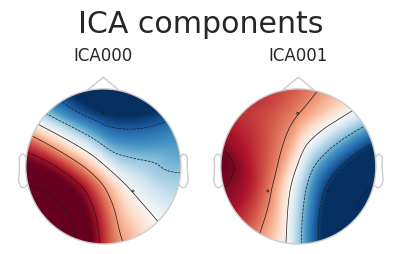

Creating RawArray with float64 data, n_channels=2, n_times=119000
    Range : 0 ... 118999 =      0.000 ...   475.996 secs
Ready.


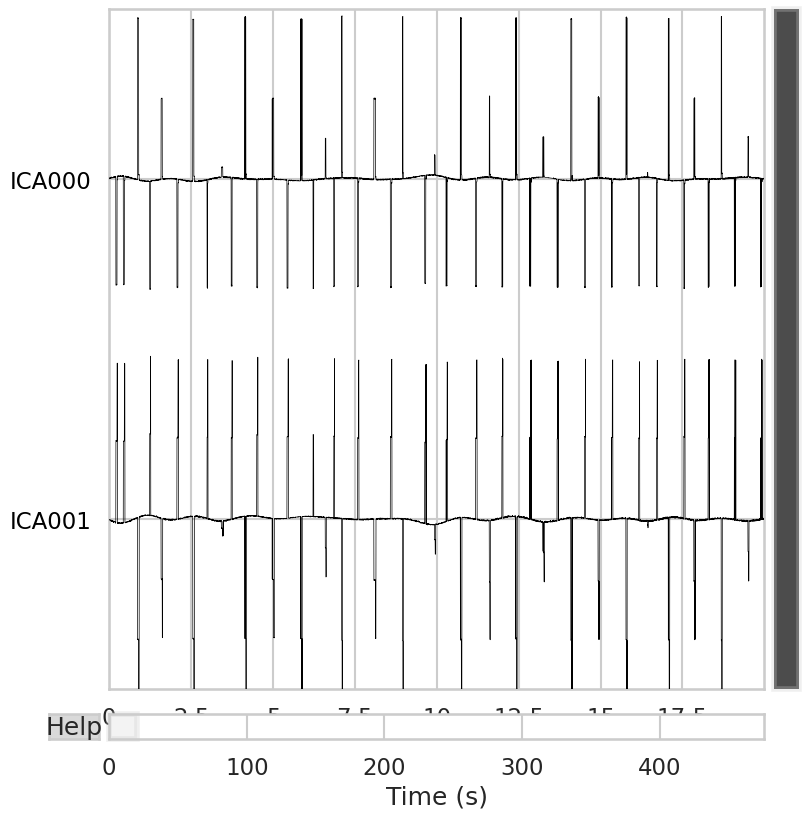

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 3 PCA components


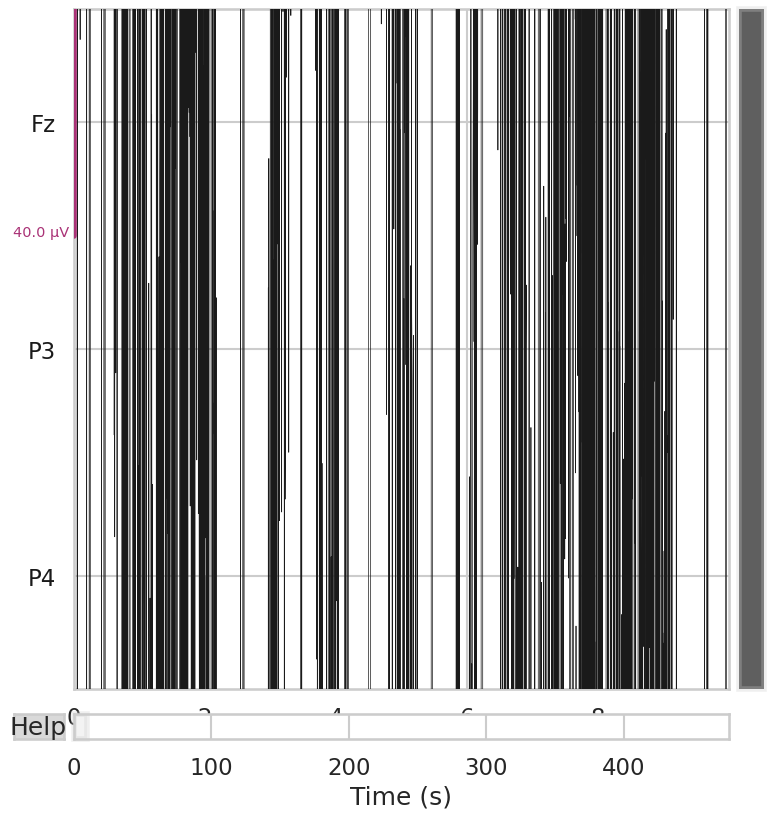

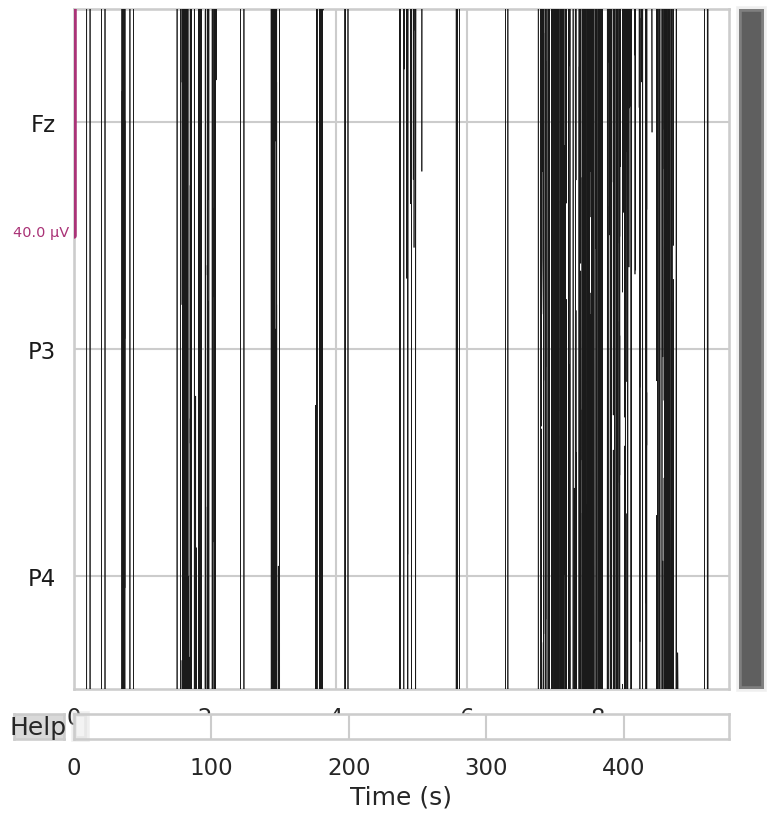

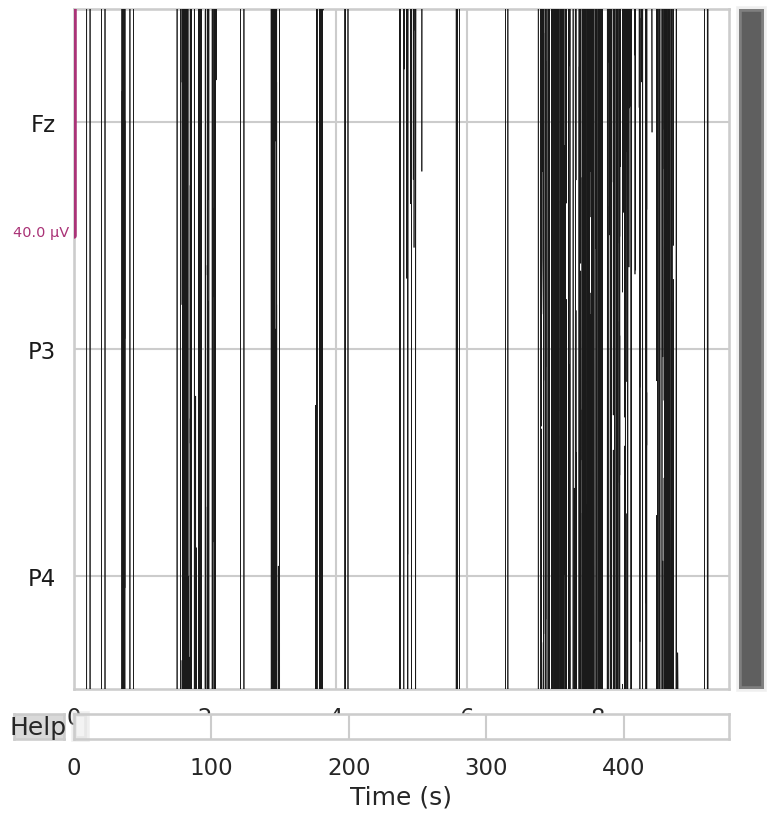

In [17]:
# NOW assign electrode positions
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

raw.set_eeg_reference("average", projection=False)

raw.filter(l_freq=1.0, h_freq=None)

ica = ICA(
    n_components=0.95, #95
    method="fastica",
    random_state=97,
    max_iter="auto"
)

ica.fit(raw)

ica.plot_components()
ica.plot_sources(raw)

ica.exclude = [0, 2]

raw_clean = ica.apply(raw.copy())

raw.plot(title="Before ICA")
raw_clean.plot(title="After ICA")


In [18]:
# Ask user for splice times
b1_start = float(input("Baseline 1 start time (seconds): "))
b1_end = float(input("Baseline 1 end time (seconds): "))

e1_start = float(input("Experimental 1 start time (seconds): "))
e1_end = float(input("Experimental 1 end time (seconds): "))

b2_start = float(input("Baseline 2 start time (seconds): "))
b2_end = float(input("Baseline 2 end time (seconds): "))

e2_start = float(input("Experimental 2 start time (seconds): "))
e2_end = float(input("Experimental 2 end time (seconds): "))

# Crop each segment
baseline1 = file.copy().crop(tmin=b1_start, tmax=b1_end)
experimental1 = file.copy().crop(tmin=e1_start, tmax=e1_end)
baseline2 = file.copy().crop(tmin=b2_start, tmax=b2_end)
experimental2 = file.copy().crop(tmin=e2_start, tmax=e2_end)


Baseline 1 start time (seconds):  158
Baseline 1 end time (seconds):  168
Experimental 1 start time (seconds):  217
Experimental 1 end time (seconds):  293
Baseline 2 start time (seconds):  311
Baseline 2 end time (seconds):  321
Experimental 2 start time (seconds):  341
Experimental 2 end time (seconds):  415


AttributeError: 'str' object has no attribute 'copy'

In [16]:
beat_first = input("Which monaural beat did the participant start with? (theta/gamma): ").strip().lower()
if beat_first not in ['theta', 'gamma']:
    raise ValueError("Invalid input! Must be 'theta' or 'gamma'.")

if beat_first == "theta":
    fz_segments = {
        "baseline": baseline1,
        "experimental": experimental1}
    parietal_segments = {
        "baseline": baseline2,
        "experimental": experimental2}
else:  #gamma was first
    parietal_segments = {
        "baseline": baseline1,
        "experimental": experimental1}
    fz_segments = {
        "baseline": baseline2,
        "experimental": experimental2}

#apply theta bandpass filter (4–8 Hz) to Fz for Fz/theta first segments
for name, seg in fz_segments.items():
    seg.filter(
        l_freq=4,
        h_freq=8,
        picks=["Fz"],
        method='iir',
        iir_params={'order': 6, 'ftype': 'butter'},  #Greater order = Harsher cutoff
        phase='zero'
    )

#apply gamma bandpass filter (30–50 Hz) to P3 and P4 for parietal/gamma first segments
for name, seg in parietal_segments.items():
    seg.filter(
        l_freq=30,
        h_freq=50,
        picks=["P3", "P4"],
        method='iir',
        iir_params={'order': 6, 'ftype': 'butter'},
        phase='zero'
    )


Which monaural beat did the participant start with? (theta/gamma):  theta


ValueError: picks (['Fz']) could not be interpreted as channel names (no channel "[np.str_('Fz')]"), channel types (no type "Fz" present), or a generic type (just "all" or "data")

In [5]:
import mne
import numpy as np
import pandas as pd
import os
import matplotlib


#matplotlib.use("TkAgg")
#Set working directory
#os.chdir("/Users/user/Desktop/Neuro Project")



#load the bdf file
raw = mne.io.read_raw_bdf("P01.bdf", preload=True)


data, times = raw.get_data(return_times=True)
df = pd.DataFrame(data.T, columns=raw.ch_names)
print(df.describe())



Extracting BDF parameters from P01.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 156999  =      0.000 ...   627.996 secs...


/tmp/ipykernel_862551/3657488485.py:15: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_bdf("P01.bdf", preload=True)


               EEG 1          EEG 2          EEG 3         EEG 4  \
count  157000.000000  157000.000000  157000.000000  1.570000e+05   
mean       -0.004350      -0.001092       0.006688 -1.464855e-03   
std         0.107208       0.099198       0.102983  2.168411e-19   
min        -0.187499      -0.187500      -0.187485 -1.464855e-03   
25%        -0.093320      -0.081558      -0.070824 -1.464855e-03   
50%        -0.022744      -0.000759      -0.001465 -1.464855e-03   
75%         0.106134       0.080939       0.115823 -1.464855e-03   
max         0.187494       0.187500       0.187500 -1.464855e-03   

               EEG 5          EEG 6          EEG 7          EEG 8  \
count  157000.000000  157000.000000  157000.000000  157000.000000   
mean        0.001449       0.001456       0.001463       0.001464   
std         0.001789       0.001475       0.001031       0.001090   
min        -0.185958      -0.185814      -0.185872      -0.185197   
25%         0.001465       0.001465       